Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 946/946 [00:05<00:00, 185.54it/s]
Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 946/946 [00:05<00:00, 186.96it/s]
c:\Users\rwcki\anaconda3\envs\torch_env\lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
Computing embeddings: 100%|██████████| 946/946 [00:26<00:00, 35.09it/s]


All similarity groups: 2
Training groups with size > 10: 0


Evaluating keypoints vs masks: 100%|██████████| 946/946 [00:07<00:00, 132.30it/s]


weights=0.500/0.100/0.400 | merged=362/500 | overall=500/500 | avg_rank_all=351.94 | rigid_aligned=362/500 | overall=500/500 | avg_rank_all=351.94
CACHE READY | all_samples=990 | distance=913 | lbp=0 | mask_ranked_records=990 | segmentation_with_mask=914 | segmentation_without_mask=32 | outside=291 | outside_person_total=291 | outside_persons_in_top_k=291 | outside_mentioned_in_merged=0
Detected: 362, Not detected: 138


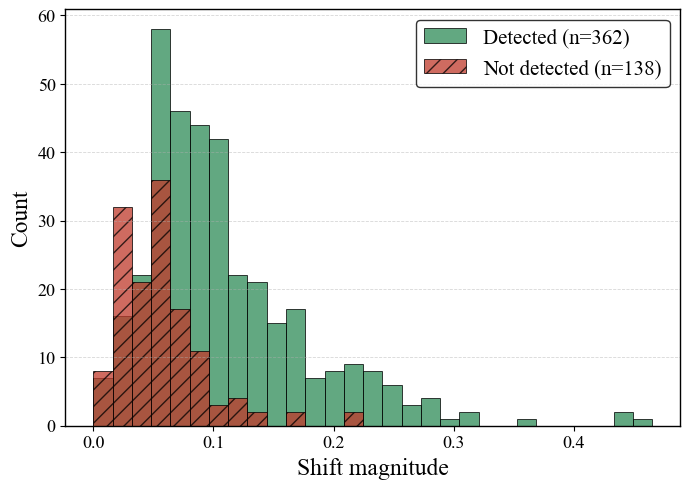

In [2]:
import ast
import math
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Ensure local package imports work when running from the notebook folder.
_repo_root = Path.cwd().resolve().parent
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

from utils.datasets import YOLOPoseDataset
from utils.validation import YPSetValidation, MergedRankingEvaluator

RESULTS_TXT_500 = r"D:\Politechnika\Deadlift_publikacja_nr_2\standard_pose_walidacja\pose_standard_flat_angle_preserving_out_500\results.txt"
TOP_K = 500

# --- Parse results.txt -> max shift magnitude per sample ---
def _parse_displacement(path):
    disp_map = {}
    with open(path, encoding="utf-8") as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            parts = line.split(" | ")
            kv = {k.strip(): v.strip() for p in parts for k, _, v in [p.partition(": ")] if _}
            img_path = kv.get("image_path", "")
            person_id_raw = kv.get("person_id")
            if not img_path or person_id_raw is None:
                continue
            try:
                person_id = int(person_id_raw)
            except (ValueError, TypeError):
                continue
            shift_vectors = ast.literal_eval(kv.get("shift_vectors", "[]"))
            mags = [math.hypot(sv[0], sv[1]) for sv in shift_vectors
                    if sv[0] != 0.0 or sv[1] != 0.0]
            max_disp = max(mags) if mags else 0.0
            key = (os.path.normcase(img_path), person_id)
            disp_map[key] = max_disp
    return disp_map

ref_displacement = _parse_displacement(RESULTS_TXT_500)

# --- Re-run evaluator to get combined_ranking (same setup as test()) ---
_dataset_500 = YOLOPoseDataset(
    r"D:\Politechnika\Deadlift_publikacja_nr_2\standard_pose_walidacja\pose_standard_flat_angle_preserving_out_500\train.txt"
)
_validator_500 = YPSetValidation(_dataset_500)
_evaluator_500 = MergedRankingEvaluator(
    validator=_validator_500,
    report_paths={"rigid_aligned": RESULTS_TXT_500},
    top_k=TOP_K,
    output_path=None,
    distance_model_name="random_forest",
    distance_visibility_threshold=2.0,
    distance_threshold_percentile=95.0,
    distance_sort_by="mean",
    segmentation_mask_tolerance_px=18,
)
_result_500 = _evaluator_500.run(
    distance_weight=0.5,
    lbp_weight=0.1,
    segmentation_weight=0.4,
)

# Set of keys detected within top-k
detected_keys = {
    (os.path.normcase(str(e["image_path"])), int(e["person_id"]))
    for e in _result_500["combined_ranking"]
    if e.get("rank", float("inf")) <= TOP_K
}

# Also count outside_mentioned_in_merged as detected (outside keys in the reference,
# which may have rank > TOP_K when there are more outside entries than TOP_K)
_outside_keys_eval = {
    key
    for key, meta in _evaluator_500.outside_lookup.items()
    if bool(meta.get("outside_mask_detected", False))
}
_outside_mentioned_keys = _outside_keys_eval & _evaluator_500.merged_reference_keys
detected_keys = detected_keys | _outside_mentioned_keys

# --- Build per-sample arrays ---
detected_disp = np.array([d for k, d in ref_displacement.items() if k in detected_keys])
not_detected_disp = np.array([d for k, d in ref_displacement.items() if k not in detected_keys])

print(f"Detected: {len(detected_disp)}, Not detected: {len(not_detected_disp)}")

# IEEE-like styling: serif fonts, neutral palette, and print-friendly lines.
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "axes.linewidth": 1.0,
})

# --- Plot ---
fig, ax1 = plt.subplots(1, 1, figsize=(7, 5), tight_layout=True)

all_disp = np.concatenate([detected_disp, not_detected_disp])
bins = np.linspace(0, all_disp.max() * 1.02, 30)

ax1.hist(
    detected_disp,
    bins=bins,
    density=False,
    alpha=0.75,
    color="#2E8B57",
    edgecolor="black",
    linewidth=0.7,
    label=f"Detected (n={len(detected_disp)})",
)
ax1.hist(
    not_detected_disp,
    bins=bins,
    density=False,
    alpha=0.75,
    color="#C0392B",
    edgecolor="black",
    linewidth=0.7,
    hatch="//",
    label=f"Not detected (n={len(not_detected_disp)})",
)

ax1.set_xlabel("Shift magnitude", fontsize=17)
ax1.set_ylabel("Count", fontsize=17)
ax1.tick_params(axis="both", labelsize=13)
ax1.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)
ax1.legend(fontsize=15, frameon=True, edgecolor="black")

plt.show()


##RIGID OUT


Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 946/946 [00:04<00:00, 192.52it/s]
Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 946/946 [00:04<00:00, 206.26it/s]
c:\Users\rwcki\anaconda3\envs\torch_env\lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
Computing embeddings: 100%|██████████| 946/946 [00:21<00:00, 44.71it/s]


All similarity groups: 2
Training groups with size > 10: 0


Evaluating keypoints vs masks: 100%|██████████| 946/946 [00:05<00:00, 164.53it/s]


weights=0.500/0.100/0.400 | merged=403/500 | overall=500/500 | avg_rank_all=312.54 | rigid_aligned=403/500 | overall=500/500 | avg_rank_all=312.54
CACHE READY | all_samples=990 | distance=913 | lbp=0 | mask_ranked_records=990 | segmentation_with_mask=914 | segmentation_without_mask=32 | outside=391 | outside_person_total=391 | outside_persons_in_top_k=391 | outside_mentioned_in_merged=0
Detected: 403, Not detected: 97
Suma absolutna (all): 111.852755
Suma absolutna (detected): 96.500924
Suma absolutna (not detected): 15.351831


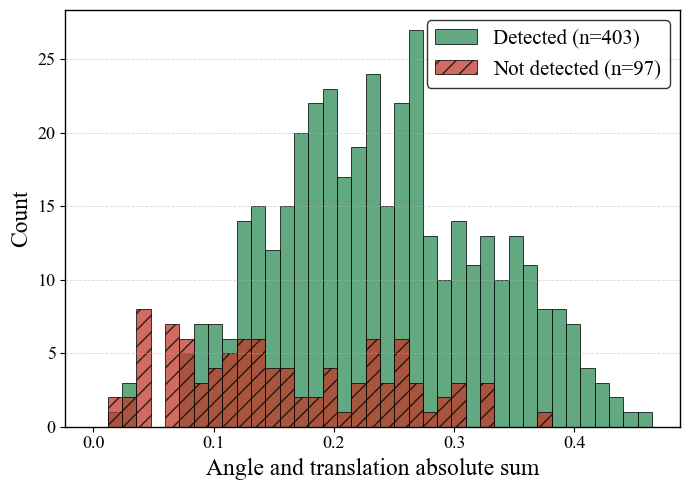

In [10]:
import ast
import math
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Ensure local package imports work when running from the notebook folder.
_repo_root = Path.cwd().resolve().parent
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

from utils.datasets import YOLOPoseDataset
from utils.validation import YPSetValidation, MergedRankingEvaluator

RESULTS_TXT_500 = r"D:\Politechnika\Deadlift_publikacja_nr_2\standard_pose_walidacja\pose_standard_flat_rigid_out_500\results.txt"
TRAIN_TXT_500 = r"D:\Politechnika\Deadlift_publikacja_nr_2\standard_pose_walidacja\pose_standard_flat_rigid_out_500\train.txt"
TOP_K = 500

# Re-run evaluator to build detected/not detected split for this dataset.
_dataset_500 = YOLOPoseDataset(TRAIN_TXT_500)
_validator_500 = YPSetValidation(_dataset_500)
_evaluator_500 = MergedRankingEvaluator(
    validator=_validator_500,
    report_paths={"rigid_aligned": RESULTS_TXT_500},
    top_k=TOP_K,
    output_path=None,
    distance_model_name="random_forest",
    distance_visibility_threshold=2.0,
    distance_threshold_percentile=95.0,
    distance_sort_by="mean",
    segmentation_mask_tolerance_px=18,
)
_result_500 = _evaluator_500.run(
    distance_weight=0.5,
    lbp_weight=0.1,
    segmentation_weight=0.4,
)

detected_keys = {
    (os.path.normcase(str(e["image_path"])), int(e["person_id"]))
    for e in _result_500["combined_ranking"]
    if e.get("rank", float("inf")) <= TOP_K
}
_outside_keys_eval = {
    key
    for key, meta in _evaluator_500.outside_lookup.items()
    if bool(meta.get("outside_mask_detected", False))
}
_outside_mentioned_keys = _outside_keys_eval & _evaluator_500.merged_reference_keys
detected_keys = detected_keys | _outside_mentioned_keys


def parse_abs_sums(path):
    rows = []
    with open(path, encoding="utf-8") as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue

            parts = line.split(" | ")
            kv = {
                k.strip(): v.strip()
                for p in parts
                for k, sep, v in [p.partition(": ")]
                if sep
            }

            image_path = kv.get("image_path", "")
            person_id_raw = kv.get("person_id")
            translation_raw = kv.get("translation_vector")
            rotation_deg_raw = kv.get("rotation_angle_degrees")
            if (
                not image_path
                or person_id_raw is None
                or translation_raw is None
                or rotation_deg_raw is None
            ):
                continue

            try:
                person_id = int(person_id_raw)
                tx, ty = ast.literal_eval(translation_raw)
                tx = float(tx)
                ty = float(ty)
                rotation_deg = float(rotation_deg_raw)
            except (ValueError, TypeError, SyntaxError):
                continue

            rotation_rad = math.radians(rotation_deg)
            abs_sum_value = abs(tx) + abs(ty) + abs(rotation_rad)
            key = (os.path.normcase(image_path), person_id)
            rows.append((key, abs_sum_value))

    return rows


rows = parse_abs_sums(RESULTS_TXT_500)
if not rows:
    raise RuntimeError("Brak rekordow z translation_vector i rotation_angle_degrees.")

abs_detected = np.array([value for key, value in rows if key in detected_keys], dtype=float)
abs_not_detected = np.array([value for key, value in rows if key not in detected_keys], dtype=float)
all_abs = np.concatenate([abs_detected, abs_not_detected])

print(f"Detected: {len(abs_detected)}, Not detected: {len(abs_not_detected)}")
print(f"Suma absolutna (all): {all_abs.sum():.6f}")
print(f"Suma absolutna (detected): {abs_detected.sum():.6f}")
print(f"Suma absolutna (not detected): {abs_not_detected.sum():.6f}")

# IEEE-like styling: serif fonts, neutral palette, and print-friendly lines.
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "axes.linewidth": 1.0,
})

# --- Plot ---
bins = np.linspace(0.0, float(all_abs.max()) * 1.02, 40)
fig, ax = plt.subplots(1, 1, figsize=(7, 5), tight_layout=True)

ax.hist(
    abs_detected,
    bins=bins,
    density=False,
    alpha=0.75,
    color="#2E8B57",
    edgecolor="black",
    linewidth=0.7,
    label=f"Detected (n={len(abs_detected)})",
)
ax.hist(
    abs_not_detected,
    bins=bins,
    density=False,
    alpha=0.75,
    color="#C0392B",
    edgecolor="black",
    linewidth=0.7,
    hatch="//",
    label=f"Not detected (n={len(abs_not_detected)})",
)

ax.set_xlabel("Angle and translation absolute sum", fontsize=17)
ax.set_ylabel("Count", fontsize=17)
ax.tick_params(axis="both", labelsize=13)
ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)
ax.legend(fontsize=15, frameon=True, edgecolor="black")

plt.show()

##AXIS OUT

c:\Users\rwcki\anaconda3\envs\torch_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 946/946 [00:05<00:00, 176.77it/s]
Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 946/946 [00:05<00:00, 170.78it/s]
c:\Users\rwcki\anaconda3\envs\torch_env\lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
Computing embeddings: 100%|██████████| 946/946 [00:25<00:00, 37.23it/s]


All similarity groups: 2
Training groups with size > 10: 0


Evaluating keypoints vs masks: 100%|██████████| 946/946 [00:06<00:00, 144.32it/s]


weights=0.500/0.100/0.400 | merged=378/500 | overall=500/500 | avg_rank_all=329.26 | rigid_aligned=378/500 | overall=500/500 | avg_rank_all=329.26
CACHE READY | all_samples=990 | distance=913 | lbp=0 | mask_ranked_records=990 | segmentation_with_mask=914 | segmentation_without_mask=32 | outside=312 | outside_person_total=312 | outside_persons_in_top_k=312 | outside_mentioned_in_merged=0
Detected: 378, Not detected: 122


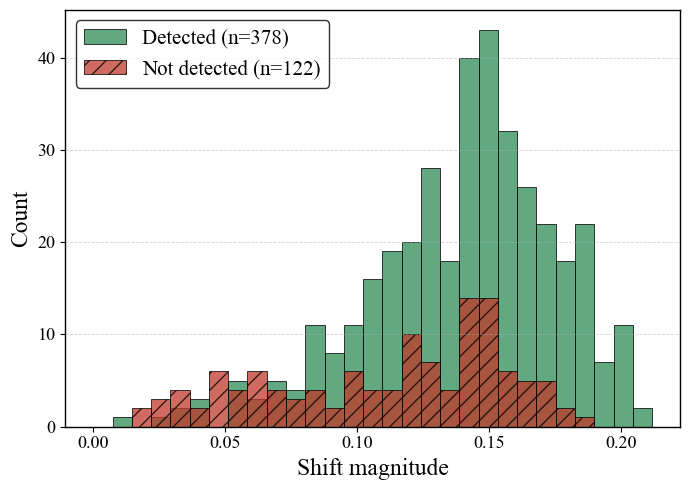

In [1]:
import ast
import math
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Ensure local package imports work when running from the notebook folder.
_repo_root = Path.cwd().resolve().parent
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

from utils.datasets import YOLOPoseDataset
from utils.validation import YPSetValidation, MergedRankingEvaluator

RESULTS_TXT_500 = r"D:\Politechnika\Deadlift_publikacja_nr_2\standard_pose_walidacja\pose_standard_flat_axis_out_500\results.txt"
TRAIN_TXT_500 = r"D:\Politechnika\Deadlift_publikacja_nr_2\standard_pose_walidacja\pose_standard_flat_axis_out_500\train.txt"
TOP_K = 500

# --- Parse results.txt -> max shift magnitude per sample ---
def _parse_displacement(path):
    disp_map = {}
    with open(path, encoding="utf-8") as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            parts = line.split(" | ")
            kv = {k.strip(): v.strip() for p in parts for k, _, v in [p.partition(": ")] if _}
            img_path = kv.get("image_path", "")
            person_id_raw = kv.get("person_id")
            if not img_path or person_id_raw is None:
                continue
            try:
                person_id = int(person_id_raw)
            except (ValueError, TypeError):
                continue
            shift_vectors = ast.literal_eval(kv.get("shift_vectors", "[]"))
            mags = [math.hypot(sv[0], sv[1]) for sv in shift_vectors
                    if sv[0] != 0.0 or sv[1] != 0.0]
            max_disp = max(mags) if mags else 0.0
            key = (os.path.normcase(img_path), person_id)
            disp_map[key] = max_disp
    return disp_map

ref_displacement = _parse_displacement(RESULTS_TXT_500)

# --- Re-run evaluator to get combined_ranking (same setup as test()) ---
_dataset_500 = YOLOPoseDataset(TRAIN_TXT_500)
_validator_500 = YPSetValidation(_dataset_500)
_evaluator_500 = MergedRankingEvaluator(
    validator=_validator_500,
    report_paths={"rigid_aligned": RESULTS_TXT_500},
    top_k=TOP_K,
    output_path=None,
    distance_model_name="random_forest",
    distance_visibility_threshold=2.0,
    distance_threshold_percentile=95.0,
    distance_sort_by="mean",
    segmentation_mask_tolerance_px=18,
)
_result_500 = _evaluator_500.run(
    distance_weight=0.5,
    lbp_weight=0.1,
    segmentation_weight=0.4,
)

# Set of keys detected within top-k
detected_keys = {
    (os.path.normcase(str(e["image_path"])), int(e["person_id"]))
    for e in _result_500["combined_ranking"]
    if e.get("rank", float("inf")) <= TOP_K
}

# Also count outside_mentioned_in_merged as detected (outside keys in the reference,
# which may have rank > TOP_K when there are more outside entries than TOP_K)
_outside_keys_eval = {
    key
    for key, meta in _evaluator_500.outside_lookup.items()
    if bool(meta.get("outside_mask_detected", False))
}
_outside_mentioned_keys = _outside_keys_eval & _evaluator_500.merged_reference_keys
detected_keys = detected_keys | _outside_mentioned_keys

# --- Build per-sample arrays ---
detected_disp = np.array([d for k, d in ref_displacement.items() if k in detected_keys])
not_detected_disp = np.array([d for k, d in ref_displacement.items() if k not in detected_keys])

print(f"Detected: {len(detected_disp)}, Not detected: {len(not_detected_disp)}")

# IEEE-like styling: serif fonts, neutral palette, and print-friendly lines.
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "axes.linewidth": 1.0,
})

# --- Plot ---
fig, ax1 = plt.subplots(1, 1, figsize=(7, 5), tight_layout=True)

all_disp = np.concatenate([detected_disp, not_detected_disp])
bins = np.linspace(0, all_disp.max() * 1.02, 30)

ax1.hist(
    detected_disp,
    bins=bins,
    density=False,
    alpha=0.75,
    color="#2E8B57",
    edgecolor="black",
    linewidth=0.7,
    label=f"Detected (n={len(detected_disp)})",
)
ax1.hist(
    not_detected_disp,
    bins=bins,
    density=False,
    alpha=0.75,
    color="#C0392B",
    edgecolor="black",
    linewidth=0.7,
    hatch="//",
    label=f"Not detected (n={len(not_detected_disp)})",
)

ax1.set_xlabel("Shift magnitude", fontsize=17)
ax1.set_ylabel("Count", fontsize=17)
ax1.tick_params(axis="both", labelsize=13)
ax1.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)
ax1.legend(fontsize=15, frameon=True, edgecolor="black")

plt.show()
